In [1]:
import pandas as pd

df = pd.read_csv("Shark Tank India.csv")

# Check data
print(df.head())

# Check columns
print(df.columns)

# Info
print(df.info())

   Season Number      Startup Name  Episode Number  Pitch Number Season Start  \
0              1     BluePineFoods               1             1    20-Dec-21   
1              1      BoozScooters               1             2    20-Dec-21   
2              1  HeartUpMySleeves               1             3    20-Dec-21   
3              1         TagzFoods               2             4    20-Dec-21   
4              1      HeadAndHeart               2             5    20-Dec-21   

  Season End Original Air Date                Episode Title           Anchor  \
0   4-Feb-22         20-Dec-21  Badlegi Business Ki Tasveer  Rannvijay Singh   
1   4-Feb-22         20-Dec-21  Badlegi Business Ki Tasveer  Rannvijay Singh   
2   4-Feb-22         20-Dec-21  Badlegi Business Ki Tasveer  Rannvijay Singh   
3   4-Feb-22         21-Dec-21      Insaan, Ideas Aur Sapne  Rannvijay Singh   
4   4-Feb-22         21-Dec-21      Insaan, Ideas Aur Sapne  Rannvijay Singh   

                       Industry 

In [2]:
df.columns = df.columns.str.strip()

In [3]:
df = df.dropna(how='all')  # remove empty rows

In [4]:
print(df.isnull().sum())

Season Number       0
Startup Name        0
Episode Number      0
Pitch Number        0
Season Start        0
                 ... 
Aman Present      170
Peyush Present    401
Ritesh Present    637
Amit Present      644
Guest Present     403
Length: 80, dtype: int64


In [5]:
industry_funding = df.groupby('Industry')['Total Deal Amount'].sum().sort_values(ascending=False)

print(industry_funding)

Industry
Beauty/Fashion                  8001.00000
Food and Beverage               7287.60005
Technology/Software             4317.00000
Medical/Health                  3993.00101
Manufacturing                   1631.00000
Lifestyle/Home                  1590.00000
Business Services               1465.00000
Children/Education              1406.00000
Fitness/Sports/Outdoors         1205.00000
Green/CleanTech                  685.01250
Vehicles/Electrical Vehicles     591.00000
Electronics                      400.00000
Entertainment                    325.00000
Animal/Pets                      305.00000
Liquor/Alcohol                   270.00000
Agriculture                      190.00000
Others                            61.30000
Hardware                          25.00000
Name: Total Deal Amount, dtype: float64


In [6]:
top_startups = df[['Startup Name', 'Total Deal Amount']].sort_values(by='Total Deal Amount', ascending=False).head(10)

print(top_startups)

        Startup Name  Total Deal Amount
484             NOOE              500.0
640         SaveSage              400.0
528     TheNaturikCo              400.0
646            Emori              300.0
482    CultureCircle              300.0
597       Beautywise              300.0
365      NasherMiles              300.0
492  KIWIKisanWindow              250.0
655     TruthAndHair              250.0
341           WeHear              250.0


In [7]:
avg_investment = df['Total Deal Amount'].mean()
print("Average Investment:", avg_investment)

Average Investment: 80.23712801843318


In [8]:
df['Total Founders'] = df['Male Present'] + df['Female Present']

gender_analysis = df[['Male Present', 'Female Present']].sum()

print(gender_analysis)

KeyError: 'Male Present'

In [9]:
print(df.columns)

Index(['Season Number', 'Startup Name', 'Episode Number', 'Pitch Number',
       'Season Start', 'Season End', 'Original Air Date', 'Episode Title',
       'Anchor', 'Industry', 'Business Description', 'Company Website',
       'Started in', 'Number of Presenters', 'Male Presenters',
       'Female Presenters', 'Transgender Presenters', 'Couple Presenters',
       'Pitchers Average Age', 'Pitchers City', 'Pitchers State',
       'Yearly Revenue', 'Monthly Sales', 'Gross Margin', 'Net Margin',
       'EBITDA', 'Cash Burn', 'SKUs', 'Has Patents', 'Bootstrapped',
       'Part of Match off', 'Original Ask Amount', 'Original Offered Equity',
       'Valuation Requested', 'Received Offer', 'Accepted Offer',
       'Total Deal Amount', 'Total Deal Equity', 'Total Deal Debt',
       'Debt Interest', 'Deal Valuation', 'Number of Sharks in Deal',
       'Deal Has Conditions', 'Royalty Percentage', 'Royalty Recouped Amount',
       'Advisory Shares Equity', 'Namita Investment Amount',
       'Nam

In [10]:
df['Total Founders'] = df['Male Presenters'] + df['Female Presenters']

gender_analysis = df[['Male Presenters', 'Female Presenters']].sum()

print(gender_analysis)

Male Presenters      1028.0
Female Presenters     391.0
dtype: float64


In [11]:
df['Funded'] = df['Total Deal Amount'].apply(lambda x: 'Yes' if x > 0 else 'No')

print(df['Funded'].value_counts())

Funded
Yes    433
No     356
Name: count, dtype: int64


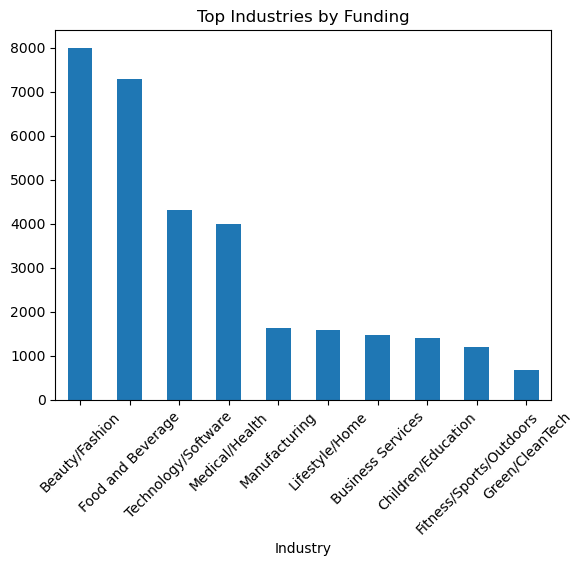

In [12]:
import matplotlib.pyplot as plt

industry_funding.head(10).plot(kind='bar')
plt.title("Top Industries by Funding")
plt.xticks(rotation=45)
plt.show()

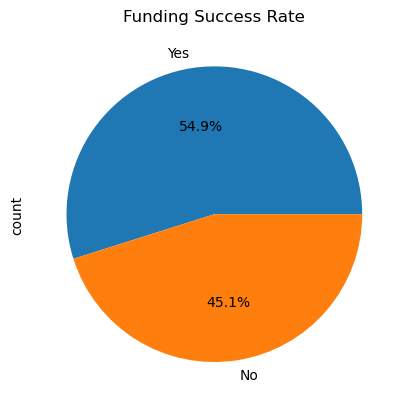

In [13]:
df['Funded'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Funding Success Rate")
plt.show()

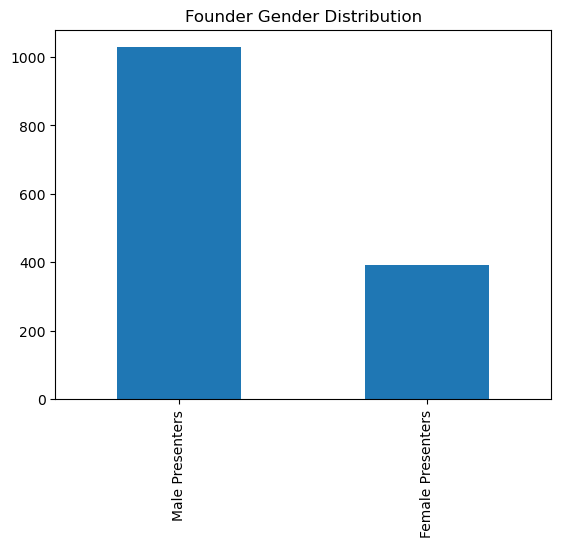

In [14]:
gender_analysis.plot(kind='bar')
plt.title("Founder Gender Distribution")
plt.show()